import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from prophet import Prophet



load dataset

In [ ]:
sales = pd.read_csv("restaurant_sales.csv", parse_dates=["date"])
weather = pd.read_csv("Daily_Weather_Insights.csv", parse_dates=["Date"])
holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])

/tmp/ipykernel_2168/2494791094.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])


In [ ]:
weather.rename(columns={"Date":"date"}, inplace=True)
holidays.rename(columns={"Date":"date"}, inplace=True)

In [ ]:
print(sales.head(5))

        date   sales
0 2025-01-01  281.64
1 2025-01-02  212.74
2 2025-01-03  250.61
3 2025-01-04  253.38
4 2025-01-05  253.00


In [ ]:
sales.index=sales['date']

In [ ]:
print(sales.head(5))

                 date   sales
date                         
2025-01-01 2025-01-01  281.64
2025-01-02 2025-01-02  212.74
2025-01-03 2025-01-03  250.61
2025-01-04 2025-01-04  253.38
2025-01-05 2025-01-05  253.00


In [ ]:
del sales['date']

In [ ]:
print(sales.head(5))

             sales
date              
2025-01-01  281.64
2025-01-02  212.74
2025-01-03  250.61
2025-01-04  253.38
2025-01-05  253.00


In [ ]:
sales.isnull().sum().sum()

np.int64(0)

In [ ]:
sales.duplicated().sum()

np.int64(6)

In [ ]:
sales.drop_duplicates(inplace=True)

In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
print(weather.head(5))

        date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0 2025-01-01  Cairo                   16.9                  14.1   
1 2025-01-02  Cairo                   15.1                   5.6   
2 2025-01-03  Cairo                   25.1                  18.2   
3 2025-01-04  Cairo                   28.9                   9.9   
4 2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2                

In [ ]:
weather.index=weather['date']

In [ ]:
del weather['date']

In [ ]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

In [ ]:
weather.isnull().sum().sum()

np.int64(0)

In [ ]:
weather.duplicated().sum()

np.int64(0)

In [ ]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [ ]:
print(holidays.head(5))

  Country  Year                 date               Holiday_Name  Local_Name  \
0      IN  2025  2025-01-01 00:00:00             New Year's Day         NaN   
1      IN  2025  2025-02-01 00:00:00       Last day of Hanukkah         NaN   
2      IN  2025  2025-06-01 00:00:00  Guru Govind Singh Jayanti         NaN   
3      IN  2025  2025-01-13 00:00:00                      Lohri         NaN   
4      IN  2025  2025-01-14 00:00:00                     Pongal         NaN   

                         Type  
0            Optional holiday  
1                  Observance  
2            Optional holiday  
3                  Observance  
4  Hinduism, Optional holiday  


In [ ]:
holidays['date'] = pd.to_datetime(holidays['date'], format='%Y-%m-%d', errors='coerce')

In [ ]:
holidays.index=holidays['date']

In [ ]:
del holidays['date']
del holidays['Local_Name']
#del holidays['Description']

In [ ]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10540 entries, 2025-01-01 to NaT
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       10540 non-null  object
 1   Year          10540 non-null  int64 
 2   Holiday_Name  10540 non-null  object
 3   Type          10540 non-null  object
dtypes: int64(1), object(3)
memory usage: 411.7+ KB


In [ ]:
print(holidays['Type'].value_counts())

Type
United Nations observance            1950
Observance                           1676
Local holiday                        1572
Local observance                      964
Hebrew                                583
Christian                             495
Worldwide observance                  493
National holiday                      412
Observance, Christian                 345
Muslim                                278
Season                                220
Common local holiday                  211
Orthodox                              198
Observance, Hebrew                    187
Hinduism, Optional holiday            145
Optional holiday                      117
National holiday, Christian           102
Observance, Muslim                     94
Clock change/Daylight Saving Time      88
Sporting event                         78
Observance, Orthodox                   66
National holiday, Hinduism             65
Local holiday, Christian               55
Hinduism                     

In [ ]:
print(holidays.head(5))

           Country  Year               Holiday_Name  \
date                                                  
2025-01-01      IN  2025             New Year's Day   
2025-02-01      IN  2025       Last day of Hanukkah   
2025-06-01      IN  2025  Guru Govind Singh Jayanti   
2025-01-13      IN  2025                      Lohri   
2025-01-14      IN  2025                     Pongal   

                                  Type  
date                                    
2025-01-01            Optional holiday  
2025-02-01                  Observance  
2025-06-01            Optional holiday  
2025-01-13                  Observance  
2025-01-14  Hinduism, Optional holiday  


In [ ]:
holidays.isnull().sum().sum()

np.int64(0)

In [ ]:
holidays.duplicated().sum()

np.int64(410)

In [ ]:
holidays.drop_duplicates(inplace=True)

In [ ]:
# Merge sales with weather and holidays
df = sales.merge(weather, on="date", how="left")
df = df.merge(holidays, on="date", how="left")

# Ensure df has a unique DatetimeIndex by dropping duplicate dates,
# keeping the first occurrence. This is crucial for time series analysis
# that expects a regular frequency and no duplicate timestamps.
df = df.loc[~df.index.duplicated(keep='first')]

In [ ]:
df

,sales,City,Temperature_High (°C),Temperature_Low (°C),Humidity (%),Wind_Speed (km/h),Weather_Condition,Air_Quality_Index,Precipitation (mm),Visibility (km),Country,Year,Holiday_Name,Type
date,,,,,,,,,,,,,,
2025-01-01,281.64,Cairo,16.9,14.1,43.1,24.2,Sunny,145.0,17.2,4.7,IN,2025.0,New Year's Day,Optional holiday
2025-01-02,212.74,Cairo,15.1,5.6,56.9,8.2,Windy,115.0,0.5,9.8,NaN,NaN,NaN,NaN
2025-01-03,250.61,Cairo,25.1,18.2,52.5,18.2,Snowy,11.0,6.0,2.5,NaN,NaN,NaN,NaN
2025-01-04,253.38,Cairo,28.9,9.9,76.3,18.8,Rainy,22.0,6.8,9.4,NaN,NaN,NaN,NaN
2025-01-05,253.00,Cairo,17.6,13.7,55.6,10.8,Sunny,39.0,12.6,4.5,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,315.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-28,315.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,245.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum().sum()

np.int64(3806)

In [ ]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_holiday"] = df["Holiday_Name"].notnull().astype(int)

plot sales trend

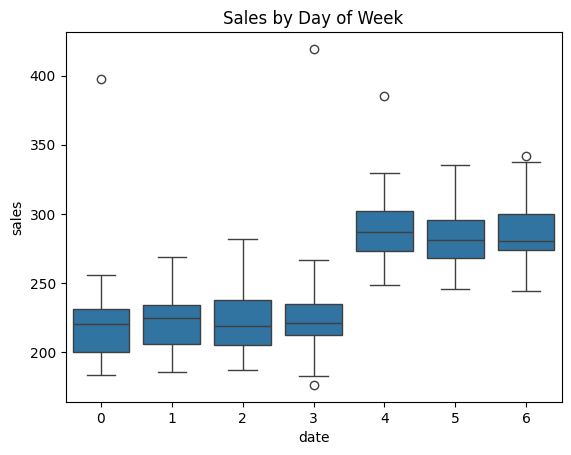

In [ ]:
sns.boxplot(x=df.index.dayofweek, y=df['sales'])
plt.title("Sales by Day of Week")
plt.show()


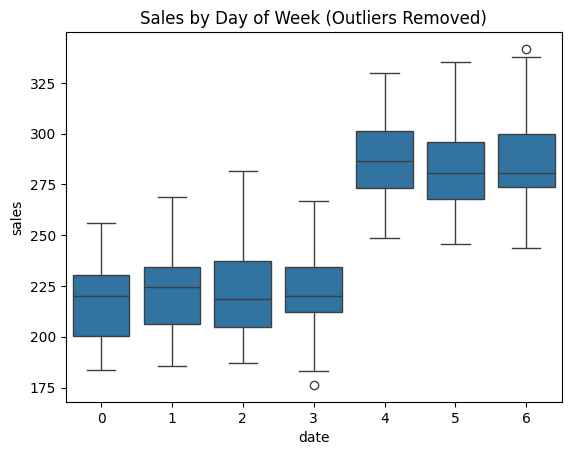

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

# Compute the IQR
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers = df[(df['sales'] >= lower_bound) & (df['sales'] <= upper_bound)]

# Plot again without outliers
sns.boxplot(x=df_no_outliers.index.dayofweek, y=df_no_outliers['sales'])
plt.title("Sales by Day of Week (Outliers Removed)")
plt.show()


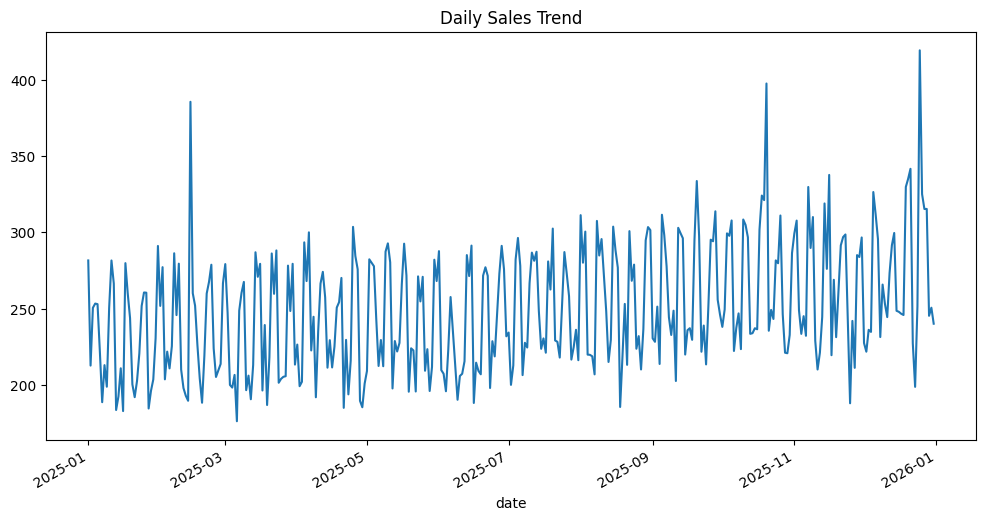

In [ ]:
plt.figure(figsize=(12,6))
sales['sales'].plot(title="Daily Sales Trend")
plt.show()

In [ ]:
# Optional: cap extreme outliers (holiday spikes)
q_low, q_high = sales['sales'].quantile([0.01, 0.99])
sales['sales'] = np.clip(sales['sales'], q_low, q_high)

In [ ]:
q_high

339.36000000000007

In [ ]:
q_low

184.8694

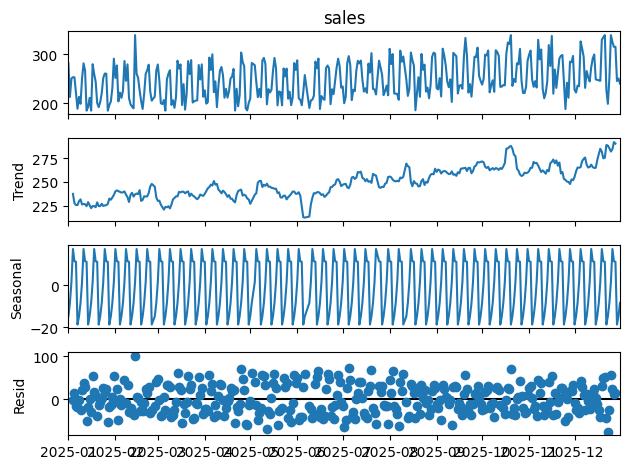

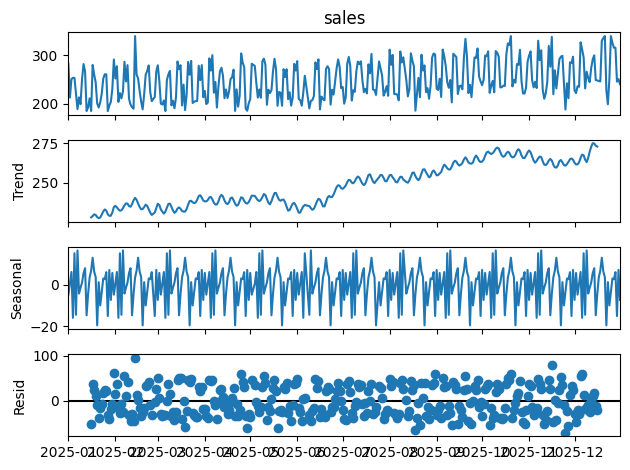

In [ ]:
# eda: decompose seasonality (weekly pattern)
result = seasonal_decompose(sales['sales'], model='additive', period=7)
result.plot()
plt.show()

# Monthly decomposition (if dataset spans >1 year)
result_month = seasonal_decompose(sales['sales'], model='additive', period=30)
result_month.plot()
plt.show()


<Figure size 1200x400 with 0 Axes>

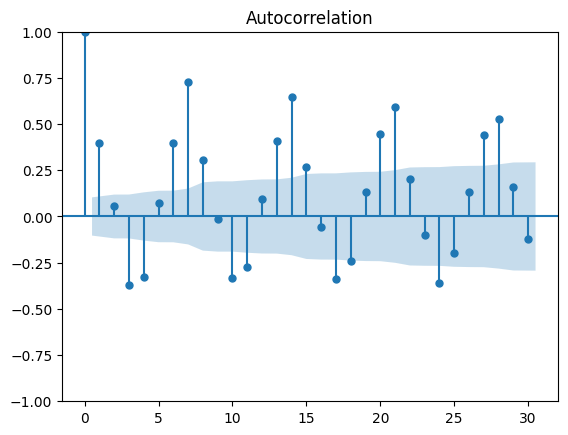

<Figure size 1200x400 with 0 Axes>

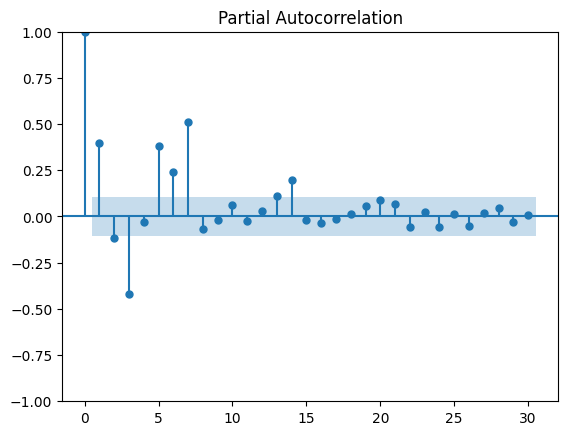

In [ ]:
# eda: autocorrelation & partial autocorrelation
plt.figure(figsize=(12,4))
plot_acf(sales['sales'].dropna(), lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sales['sales'].dropna(), lags=30)
plt.show()


ACF (Autocorrelation Function): Shows correlation of the series with its own lagged values. Useful for detecting MA (moving average) terms.

PACF (Partial Autocorrelation Function): Shows correlation after removing effects of shorter lags. Useful for detecting AR (autoregressive) terms.

Peaks outside the confidence interval (blue shaded area) indicate significant correlation at that lag.

Seasonality check

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result=adfuller(sales['sales'])

In [ ]:
print(result[1])

0.7990342467236713


In [ ]:
p_value=result[1]

In [ ]:
if p_value < 0.05:
  print("accepted as stationary")
else:
  print("rejected as non stationary")

rejected as non stationary


non-stationary so doing differencing

In [ ]:
rolling_mean=df['sales'].rolling(window=12).mean()
df_new=df['sales']-rolling_mean

df_new.head(15)

,sales
date,
2025-01-01,NaN
2025-01-02,NaN
2025-01-03,NaN
2025-01-04,NaN
2025-01-05,NaN
2025-01-06,NaN
2025-01-07,NaN
2025-01-08,NaN
2025-01-09,NaN


In [ ]:
df_new.dropna(inplace=True)

In [ ]:
df_new

,sales
2025-01-12,27.114167
2025-01-13,-47.598333
2025-01-14,-37.032500
2025-01-15,-15.269167
2025-01-16,-37.438333
...,...
2025-12-27,24.946667
2025-12-28,19.378333
2025-12-29,-50.540000
2025-12-30,-45.638333


<Axes: title={'center': 'differenced data'}, xlabel='date'>

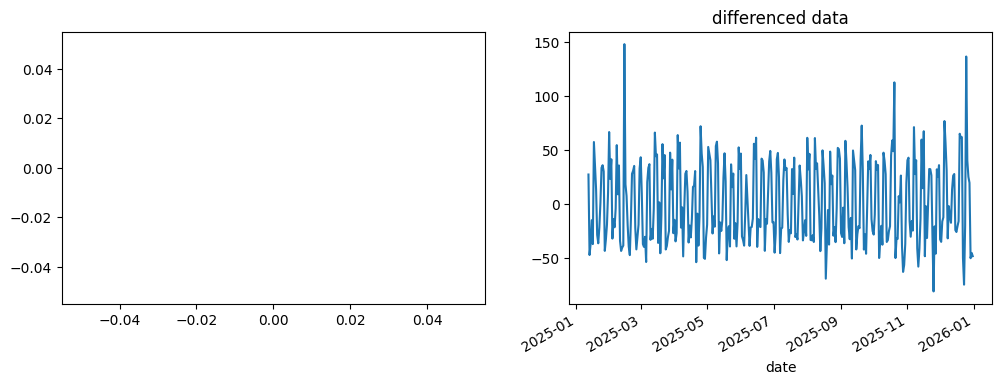

In [ ]:
#on 12th moving avg starts
ax1=plt.subplot(1,2,1)
ax1.plot(figsize=(12,4),color='tab:red',title ='original data',ax=ax1)
ax2=plt.subplot(1,2,2)
df_new.plot(figsize=(12,4),color='tab:blue',title='differenced data',ax=ax2)


In [ ]:
import pandas as pd

# Re-create df_new to ensure its values are numeric and index is DatetimeIndex
# This addresses the persistent 'object' dtype issues and 'sales' in the index.
df_new = df['sales'] - df['sales'].rolling(window=12).mean()
df_new = pd.to_numeric(df_new, errors='coerce') # Ensure values are numeric
df_new.index = pd.to_datetime(df_new.index, errors='coerce') # Ensure index is datetime
df_new.dropna(inplace=True) # Drop NaNs after coercion

# Create a complete daily date range from the min to max date in df_new's index
full_date_range = pd.date_range(start=df_new.index.min(), end=df_new.index.max(), freq='D')

# Reindex df_new to the full date range to ensure a continuous daily frequency
df_new = df_new.reindex(full_date_range)

# Now that the index is continuous and daily, explicitly set the frequency.
# This helps statsmodels correctly interpret the time series.
df_new.index.freq = 'D'

m = df_new.rolling(window=12).mean()
s = df_new.rolling(window=12).std()

# Ensure m and s also have proper DatetimeIndex and numeric values with 'D' frequency
# The frequency is inherited from df_new, so explicit setting is not needed.
m = pd.to_numeric(m, errors='coerce')
m.dropna(inplace=True)

s = pd.to_numeric(s, errors='coerce')
s.dropna(inplace=True)

In [ ]:
print(m)

In [ ]:
print(s)

In [ ]:
import numpy as np

# Identify numeric columns in df to fill with 0
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# The 'Year' column is datetime and has NaNs.
# Filling datetime NaNs with 0 is inappropriate. You can leave them as NaT or handle them specifically.
# df['Year'] = df['Year'].fillna(pd.Timestamp('1970-01-01')) # Example: fill with a placeholder date

print("NaN values in numeric columns of 'df' have been replaced with 0.")
print(f"Total remaining NaN values in df: {df.isnull().sum().sum()}")

In [ ]:
#splitting of data manually
print(df_new.shape)
train = df_new[:330].astype(float)
train.shape
test = df_new[330:].astype(float)
test.shape

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train,order=(1,0,1))
model_fit=model.fit()

In [ ]:
df_new.name = None
m.name = None
s.name = None

# Plotting directly using the cleaned Series index and values
plt.plot(df_new.index, df_new.values, color='blue', label='df_new')
plt.plot(m.index, m.values, color='red', label='rolling mean')
plt.plot(s.index, s.values, color='green', label='rolling std')
plt.legend()
plt.show()

In [ ]:
predictions = model_fit.predict(start=len(train),end=len(train)+len(test)-1,typ='levels')
# Ensure predictions have the correct time index from the test set
predictions.index = test.index

# Create a full-length series for predictions, filled with NaNs for the training period
full_predictions = pd.Series(index=df_new.index, dtype=float)
full_predictions.loc[predictions.index] = predictions

# Create the DataFrame for plotting
plot_df = pd.DataFrame({'sales_differenced': df_new, 'predict': full_predictions})
plot_df[['sales_differenced','predict']].plot(figsize=(12,4))

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install pmdarima

In [ ]:
from pmdarima import auto_arima

In [ ]:
# Ensure df_new is numeric, coercing any non-numeric values to NaN
df_new_numeric = pd.to_numeric(df_new, errors='coerce')
# Drop any NaNs that resulted from coercion or were already present
data_for_arima = df_new_numeric.dropna().values

auto=auto_arima(data_for_arima)
auto.summary()

according to auto arima MODEL : SARIMAX(3,0,2)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model1=SARIMAX(train,order=(3,0,2),seasonal_order=(3,0,2,12))
model_fit1=model1.fit()

In [ ]:
df_new['sales']=model_fit1.predict(start=len(train),end=len(train)+len(test)-1)

In [ ]:
plot_df[['sales_differenced','predict']].plot()

forecasting

In [ ]:
forcasted=model_fit1.forecast(steps=12)

In [ ]:
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Plot historical differenced sales
plot_df['sales_differenced'].plot(ax=ax, label='Historical Differenced Sales', color='blue')

# Plot forecasted values
forcasted.plot(ax=ax, label='Forecasted Sales', color='red', linestyle='--')

plt.title('Historical Differenced Sales vs. Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])

In [ ]:
df.isnull().sum().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y', errors='coerce')

In [ ]:
X=df.drop(columns=['sales'])
y=df['sales']

In [ ]:
X.head(5)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
model=LinearRegression()
rfe=RFE(model)
rfe.fit(X,y)
column_name=X.columns,select_indices=[i for i,x in enumerate(rfe.support_) if x]
print(column_name

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Filter potential_features to include only existing numerical columns in df
existing_numerical_features = [col for col in potential_features if col in df.columns and np.issubdtype(df[col].dtype, np.number)]

x_train, x_test, y_train, y_test = train_test_split(
    df[existing_numerical_features],
    df[target_variable],
    test_size=0.80,
    random_state=42
)

In [ ]:
import numpy as np
# List all potential numerical features that are not the target 'sales'
potential_features = [
    'City', 'Temperature_High (°C)', 'Temperature_Low (°C)', 'Humidity (%)',
    'Wind_Speed (km/h)', 'Weather_Condition', 'Air_Quality_Index',
    'Precipitation (mm)', 'Visibility (km)', 'Country', 'Holiday_Name', 'Type',
    'day_of_week', 'month', 'is_weekend', 'is_holiday', 'temperature', 'rainfall', 'is_eventday'
]

# Filter features to only include those present in df and are numerical
#current_numerical_features = [col for col in potential_features if col in df.columns and np.issubdtype(df[col].dtype, np.number)]

# Create a temporary DataFrame with selected features and the target variable, then drop NaNs
temp_df_robust = df[current_numerical_features + ['sales']].dropna()

# Check if temp_df_robust is still empty after dropping NaNs (unlikely after NaN filling, but good practice)
if temp_df_robust.empty:
    print("Warning: temp_df_robust is empty after feature selection and NaN removal. Cannot train models.")
    # Initialize empty dataframes to prevent further errors
    X_train = pd.DataFrame()
    X_test = pd.DataFrame()
    y_train = pd.Series()
    y_test = pd.Series()
else:
    X = temp_df_robust[current_numerical_features]
    y = temp_df_robust['sales']

    # Time-based train-test split for the robustly prepared data
    train_size_split = int(len(X) * 0.8)
    X_train, X_test = X[:train_size_split], X[train_size_split:]
    y_train, y_test = y[:train_size_split], y[train_size_split:]
# --- END MODIFICATION FOR EMPTY X_TRAIN/X_TEST ---


# Baseline Linear Regression
# Imports for models are expected to be in cK1gki9rRTVA
if not X_train.empty and not y_train.empty:
    lr = LinearRegression().fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    print("Linear Regression model fitted and predicted.")
else:
    print("Skipping Linear Regression due to empty X_train or y_train.")

# Random Forest
if not X_train.empty and not y_train.empty:
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    print("Random Forest model fitted and predicted.")
else:
    print("Skipping Random Forest due to empty X_train or y_train.")

# XGBoost
if not X_train.empty and not y_train.empty:
    xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    print("XGBoost model fitted and predicted.")
else:
    print("Skipping XGBoost due to empty X_train or y_train.")

# Prophet (requires ds,y format)
# Ensure prophet_df uses the combined 'df' for potential future regressors
prophet_df = df.reset_index().rename(columns={"date":"ds","sales":"y"})

# Check if prophet_df is empty before fitting Prophet model
if prophet_df.empty:
    print("Warning: prophet_df is empty. Cannot train Prophet model.")
    forecast = pd.DataFrame() # Initialize empty forecast to prevent further errors
else:
    prophet = Prophet(daily_seasonality=True, yearly_seasonality=True)
    prophet.fit(prophet_df)
    future = prophet.make_future_dataframe(periods=30)
    forecast = prophet.predict(future)
    print("Prophet model fitted and predicted.")


Features

In [ ]:
weather['avg_temp'] = (weather['Temperature_High (°C)'] + weather['Temperature_Low (°C)']) / 2

# Ensure weather index is unique before assigning to df
# This handles the duplicates introduced by the merge with 'events'
# We keep the first occurrence as the weather values (temp, precip) should be identical for duplicate dates
weather_deduplicated = weather.loc[~weather.index.duplicated(keep='first')].copy()

df['temperature'] = weather_deduplicated['avg_temp']
df['rainfall'] = weather_deduplicated['Precipitation (mm)']

In [ ]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    print(f"{model_name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

# Feature importance (Random Forest)
importances = rf.feature_importances_
features = X_train.columns
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

# Forecast visualization
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_xgb, label="XGBoost Prediction")
plt.legend()
plt.title("Demand Forecast vs Actuals")
plt.show()

# Prophet visualization
prophet.plot(forecast)
prophet.plot_components(forecast)


In [ ]:
print(weather['avg_temp'])

In [ ]:
# Event calendar
events = pd.read_csv("/content/Global_Holidays_2025_2035.csv")
events


In [ ]:
print(events.head(5))

In [ ]:
print(events.info())

In [ ]:
print(events.describe())

In [ ]:
print(events.isnull().sum())

In [ ]:
events.Local_Name.unique()

In [ ]:
events.drop(columns='Local_Name', inplace=True, errors='ignore')

In [ ]:
events.drop(columns='Description', inplace=True, errors='ignore')

In [ ]:
events.isnull().sum()

In [ ]:
print(events.duplicated().sum())

In [ ]:
events.drop_duplicates(inplace=True)

In [ ]:
events['Date'] = pd.to_datetime(events['Date'], format='%Y-%m-%d', errors='coerce')

In [ ]:
events.set_index('Date',inplace=True)

In [ ]:
events.info()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
for i in events.columns:
  if events[i].dtype=='object':
    events[i]=le1.fit_transform(events[i])

In [ ]:
events.info()

In [ ]:
events['Year'] = pd.to_datetime(events['Year'], format='%Y')

In [ ]:
df = df.merge(events, left_index=True, right_index=True, how='left')

In [ ]:
events['is_holiday']=events['Holiday_Name'].notnull().astype(int)
events['is_eventday']=events['Type'].notnull().astype(int)

In [ ]:
df.isnull().sum()

In [ ]:
# Identify numeric columns to fill with 0
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Datetime columns should ideally be left with NaT or handled specifically if a fill value is truly needed
# For now, we'll leave datetime NaNs as NaT as filling with 0 is inappropriate.
# df['Year'] = df['Year'].fillna(pd.NaT) # If you explicitly wanted to fill, this is the way


In [ ]:
df.isnull().sum().sum()

In [ ]:
df.shape

In [ ]:
print(df)

model building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Prepare features
features = ['lag_7','lag_30','rolling_7','rolling_14','day_of_week','month','is_weekend']

# Create a temporary DataFrame with features and the target variable, then drop NaNs
temp_df = df[features + ['sales']].dropna()

X = temp_df[features]
y = temp_df['sales']

# Initialize the Linear Regression model
lr = LinearRegression()

# 3. Apply RFE to select top 15 features
rfe = RFE(estimator=lr, n_features_to_select=len(features)) # Using all features since it's less than 15
rfe.fit(X, y)

# 4. Results
print("Selected Features (True=Selected):", rfe.support_)
print("Feature Ranking:", rfe.ranking_)

In [ ]:
# Prepare features
features = ['lag_7','lag_30','rolling_7','rolling_14','day_of_week','month','is_weekend']

# Create a temporary DataFrame with features and the target variable, then drop NaNs
temp_df = df[features + ['sales']].dropna()

X = temp_df[features]
y = temp_df['sales']

In [ ]:
print(features)

In [ ]:
print(X)

In [ ]:
print(y)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from prophet import Prophet

# Train-test split
train_size = int(len(df)*0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train, y_train = train.drop(columns=['sales']), train['sales']
X_test, y_test = test.drop(columns=['sales']), test['sales']

# Baseline Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Prophet (requires ds,y format)
prophet_df = sales.reset_index().rename(columns={"date":"ds","sales":"y"})
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True)
prophet.fit(prophet_df)
future = prophet.make_future_dataframe(periods=30)
forecast = prophet.predict(future)


In [ ]:
# Re-creating X and y to ensure consistent lengths
# This addresses the observed discrepancy where y had 6078 rows and X had 1046 rows.
features = ['lag_7','lag_30','rolling_7','rolling_14','day_of_week','month','is_weekend']

temp_df = df[features + ['sales']].dropna()
X = temp_df[features]
y = temp_df['sales']

print(f"Length of X after re-creation: {len(X)}")
print(f"Length of y after re-creation: {len(y)}")

In [ ]:
# Train-test split (time-based)
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
# Baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Advanced model
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

Evaluation & Visualization

In [ ]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_xgb, "XGBoost")


In [ ]:
#Plot predictions vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_xgb, label="Predicted (XGB)")
plt.legend()
plt.title("Forecast vs Actual Sales")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Load datasets
sales = pd.read_csv("sales.csv", parse_dates=["date"])
weather = pd.read_csv("weather.csv", parse_dates=["date"])
events = pd.read_csv("events.csv", parse_dates=["date"])

# Merge datasets
df = sales.merge(weather, on="date").merge(events, on="date")

# Feature engineering
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["lag_7"] = df["sales"].shift(7)
df["rolling_14"] = df["sales"].rolling(14).mean()

# Fill missing values
df = df.fillna(method="bfill").fillna(method="ffill")


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features
store_encoder = LabelEncoder()
df["store_id_enc"] = store_encoder.fit_transform(df["store_id"])

# Scale continuous features
scaler = StandardScaler()
df[["sales","temperature","rainfall"]] = scaler.fit_transform(df[["sales","temperature","rainfall"]])


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Multi-head attention block
def attention_block(inputs, num_heads=4, key_dim=32):
    return layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)

# Gated Residual Network (GRN)
def grn(inputs, hidden_units=32):
    x = layers.Dense(hidden_units, activation="elu")(inputs)
    x = layers.Dense(hidden_units)(x)
    gate = layers.Dense(hidden_units, activation="sigmoid")(inputs)
    return layers.LayerNormalization()(x * gate + inputs)


In [ ]:
# Inputs
sales_in = layers.Input(shape=(30,1), name="sales")          # past sales
weather_in = layers.Input(shape=(30,2), name="weather")      # temperature, rainfall
events_in = layers.Input(shape=(30,1), name="events")        # holiday flag

# Variable selection
sales_vs = grn(sales_in)
weather_vs = grn(weather_in)
events_vs = grn(events_in)

# Concatenate
x = layers.Concatenate()([sales_vs, weather_vs, events_vs])

# LSTM encoder-decoder
x = layers.LSTM(64, return_sequences=True)(x)
x = layers.LSTM(64, return_sequences=True)(x)

# Attention
x = attention_block(x)

# Output forecast (next 7 days)
out = layers.Dense(7)(layers.Flatten()(x))

# Model
tft_model = Model(inputs=[sales_in, weather_in, events_in], outputs=out)
tft_model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [ ]:
# Example training
history = tft_model.fit(
    {"sales": X_sales, "weather": X_weather, "events": X_events},
    y_target,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)
